In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import unicodedata

df = pd.read_csv("../data/processed/data_before_reduction.csv")

#df['price'] = np.exp(df['price'])
#df['price'] = df['price']/10000  
#df['quantity_sold'] = np.exp(df['quantity_sold'])
df.head()



,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,origin,store_id,store_name,store_review_count,total_follower,is_official,cancel_by_seller_rate,cancel_by_seller_rate_status,return_rate,return_rate_status
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.359364,0.0,3.091042,...,"Japan, Vietnam",18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,3.496508,...,Vietnam,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,3.258097,...,Vietnam,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,2.772589,...,"Japan, Vietnam",18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal
4,276626642,Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.366908,0.0,2.833213,...,Vietnam,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal


## **Câu 3: Giá sản phẩm (price) và tỷ lệ giảm giá (discount_rate) ảnh hưởng như thế nào đến số lượng bán ra (quantity_sold)?**

Mục tiêu: 
- Phân tích mối quan hệ giữa giá sản phẩm, tỷ lệ giảm giá và số lượng bán ra. Chúng ta sẽ sử dụng các phương pháp thống kê mô tả và trực quan hóa dữ liệu để trả lời câu hỏi này. 
- Thống kê xem discount_rate thì có bán được nhiều hơn so với những không discount trong cùng 1 danh mục
 

Để trả lời câu hỏi này, chúng ta sẽ phân tích mối quan hệ giữa giá sản phẩm (price), tỷ lệ giảm giá (discount_rate) và số lượng bán ra (quantity_sold) bằng cách sử dụng các biểu đồ trực quan hóa dữ liệu và các phương pháp thống kê. Chúng ta sẽ xem xét các yếu tố sau:
1. **Phân tích mô tả**: Tính toán các thống kê mô tả như trung bình, trung vị, độ lệch chuẩn của các biến price, discount_rate và quantity_sold để hiểu rõ hơn về phân phối dữ liệu.
2. **Biểu đồ Heatmap (Scatter Plot)**: Vẽ biểu đồ phân tán để quan sát mối quan hệ giữa price và quantity_sold, cũng như giữa discount_rate và quantity_sold theo nhóm danh mục.
3. **Biểu đồ cột (Bar Chart)**: So sánh số lượng bán ra trung bình giữa các nhóm sản phẩm có và không có giảm giá trong cùng một danh mục.
4. **Kiểm định thống kê**: Sử dụng các phương pháp kiểm định thống kê như hồi quy tuyến tính để xác định mức độ ảnh hưởng của price và discount_rate đến quantity_sold.

In [2]:
# Phân tích mô tả
desc = df[['price', 'discount_rate', 'quantity_sold']].describe()
print("Mô tả thống kê:")
display(desc)

Mô tả thống kê:


,price,discount_rate,quantity_sold
count,19811.000000,19811.000000,19811.000000
mean,12.594566,9.004291,2.317290
std,1.596829,13.816046,2.299663
min,9.546884,0.000000,0.000000
25%,11.532738,0.000000,0.000000
50%,12.345839,0.000000,1.791759
75%,13.290418,20.000000,3.784190
max,17.343018,52.000000,9.169977


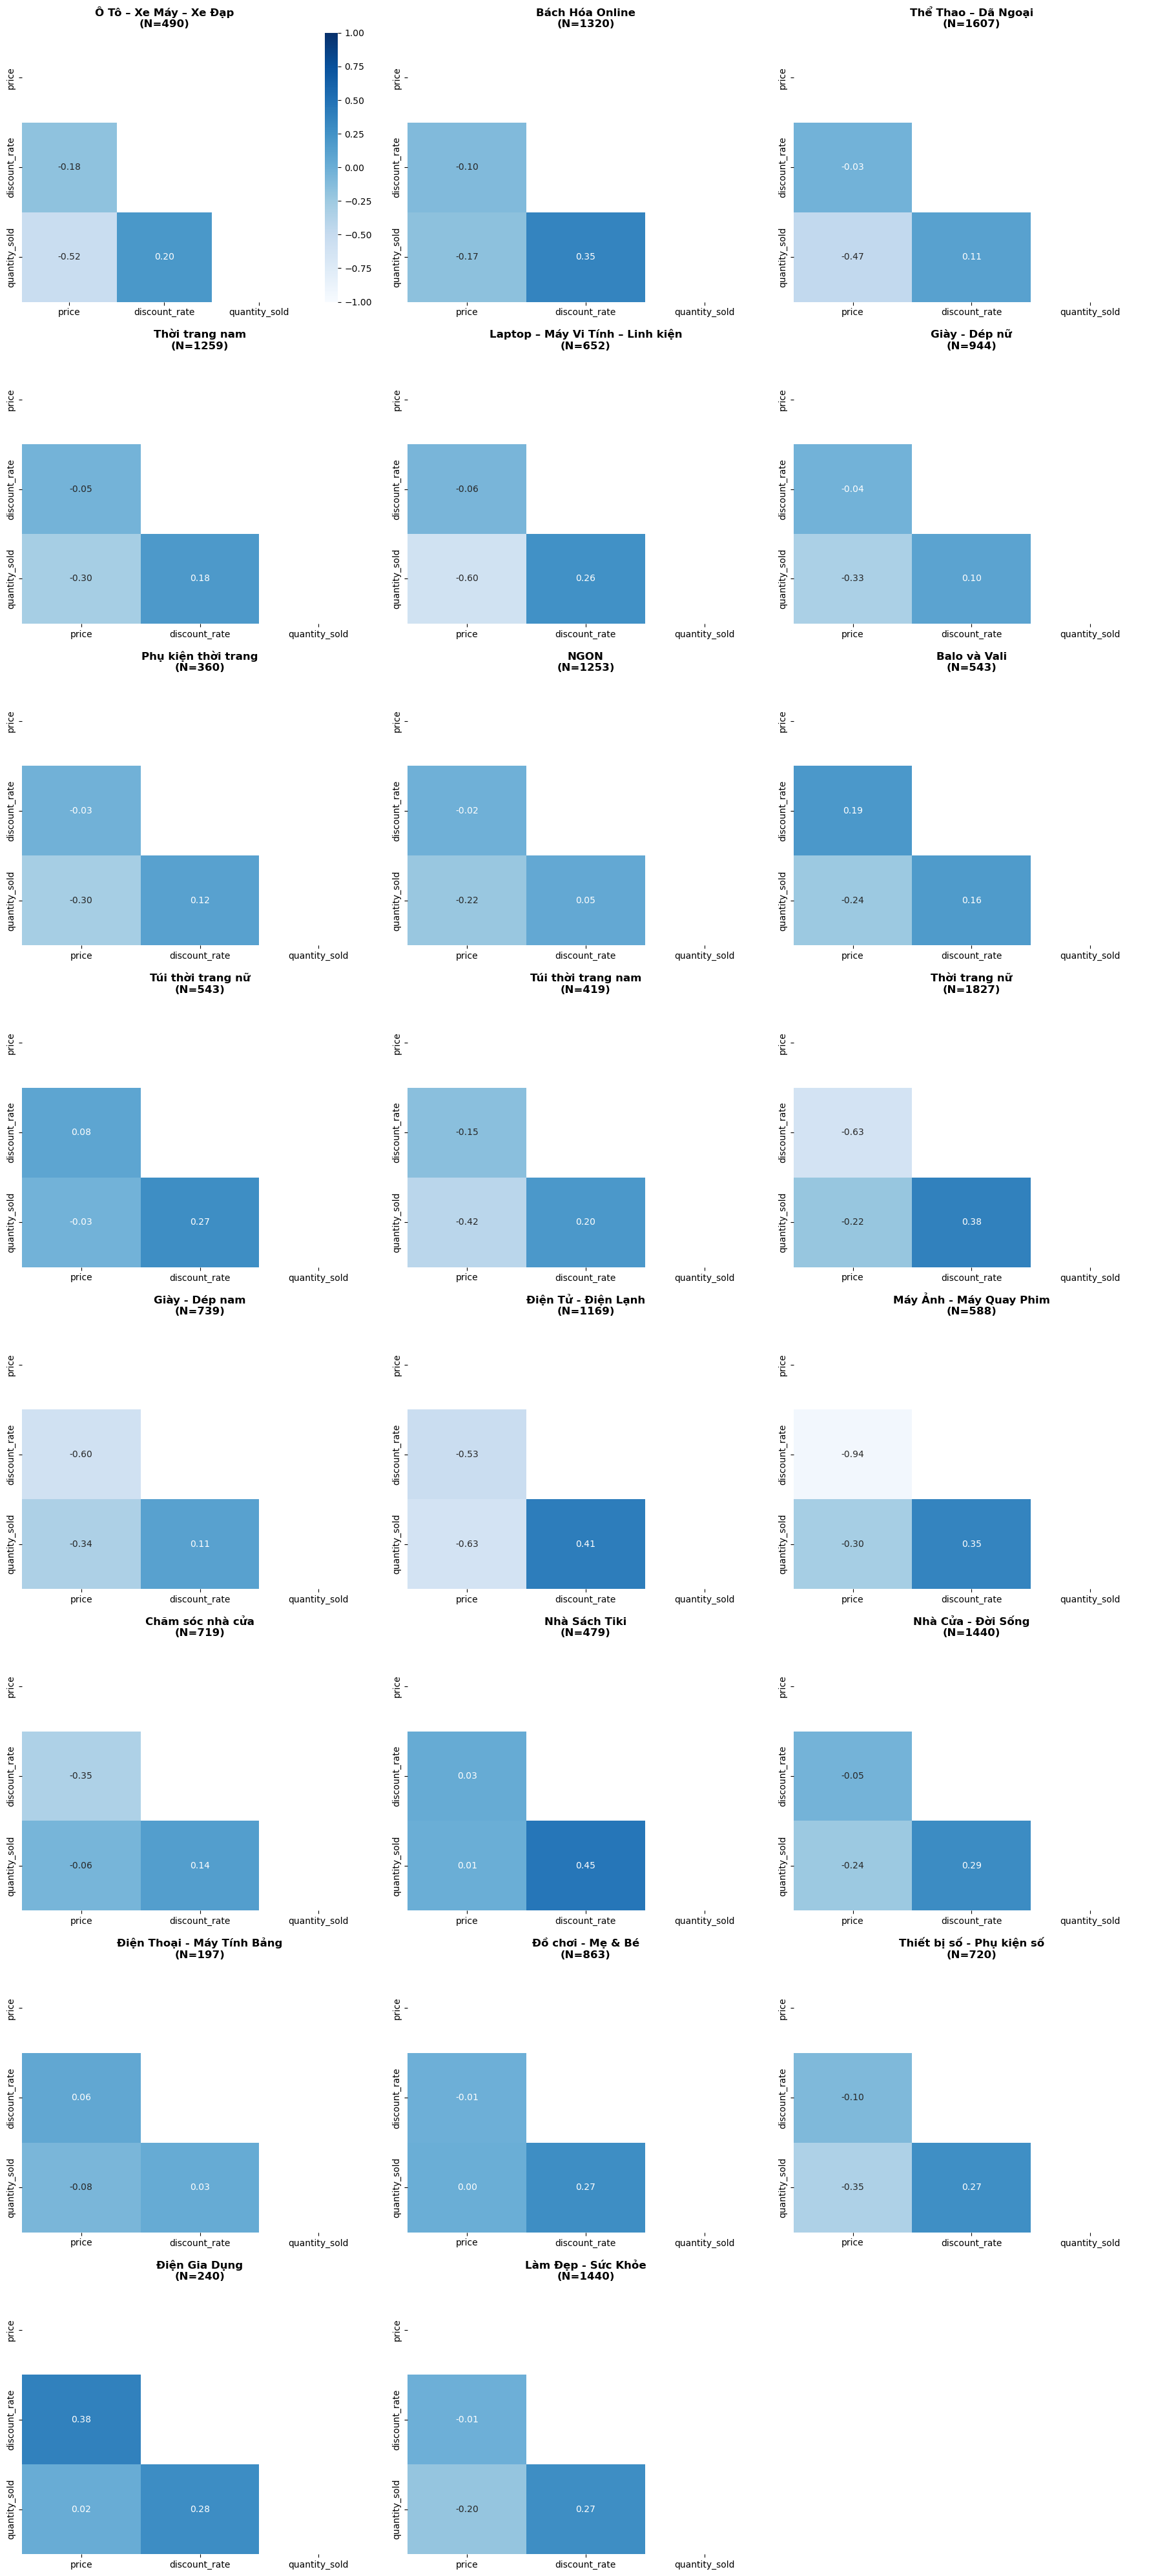

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Lọc danh sách các danh mục có đủ dữ liệu (ví dụ > 30 mẫu) để tính tương quan cho chính xác
categories = [cat for cat in df['category_root_name'].unique() 
              if len(df[df['category_root_name'] == cat]) > 30]

# 2. Thiết lập lưới biểu đồ (Grid)
n_cats = len(categories)
n_cols = 3  # Số biểu đồ trên 1 hàng (bạn có thể sửa thành 2 hoặc 4)
n_rows = math.ceil(n_cats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten() # Làm phẳng mảng axes để dễ loop

# Các cột cần tính tương quan (Thay bằng cột log của bạn nếu muốn)
cols_to_analyze = ['price', 'discount_rate', 'quantity_sold']

# 3. Vẽ vòng lặp
for i, category in enumerate(categories):
    subset = df[df['category_root_name'] == category]
    
    # Tính tương quan Spearman (Tốt cho dữ liệu biến động/phi tuyến)
    corr_matrix = subset[cols_to_analyze].corr(method='spearman')
    
    # Tạo mask để chỉ hiện nửa dưới của heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Vẽ lên trục tương ứng
    sns.heatmap(corr_matrix, 
                mask=mask,  # Thêm mask để chỉ hiện nửa dưới
                annot=True, 
                fmt=".2f", 
                cmap='Blues', 
                vmin=-1, vmax=1, 
                ax=axes[i],
                cbar=i == 0) # Chỉ hiện thanh màu ở biểu đồ đầu tiên cho đỡ rối
    
    axes[i].set_title(f'{category}\n(N={len(subset)})', fontsize=12, fontweight='bold')

# Xóa các khung biểu đồ thừa (nếu số danh mục không lấp đầy lưới)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()